# Эксперимент 1: синтетический шум с ограничениями

Этот ноутбук представляет собой контролируемый бенчмарк для NLCR. Данные генерируются с известными суммами, долями и отношениями, а базовые прогнозы строятся независимо для каждой координаты и поэтому могут нарушать ограничения.

In [1]:
from pathlib import Path
import os
import random
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.constraints import synthetic_constraints
from src.metrics import compare_forecasts
from src.stat_tests import paired_forecast_tests, paired_loss_improvements
from src.nlcr import reconcile_many
from src.plotting import (
    plot_constraint_violations,
    plot_paired_improvement_distributions,
    plot_relative_improvements,
    plot_win_rates,
)

RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

## Данные

Синтетические ряды генерируются прямо в ноутбуке. Вектор имеет вид

`[x1, x2, x3, total, s1, s2, s3, r12]`.

In [2]:
def make_demo_data(n=360, seed=42):
    rng = np.random.default_rng(seed)
    t = np.arange(n)

    x1 = 30 + 0.03 * t + 5 * np.sin(2 * np.pi * t / 24) + rng.normal(0, 1.5, n)
    x2 = 20 + 0.02 * t + 4 * np.cos(2 * np.pi * t / 30) + rng.normal(0, 1.2, n)
    x3 = 10 + 0.01 * t + 2 * np.sin(2 * np.pi * t / 12) + rng.normal(0, 0.8, n)
    x1, x2, x3 = np.maximum(x1, 1), np.maximum(x2, 1), np.maximum(x3, 1)

    total = x1 + x2 + x3
    data = pd.DataFrame({
        "x1": x1,
        "x2": x2,
        "x3": x3,
        "total": total,
        "s1": x1 / total,
        "s2": x2 / total,
        "s3": x3 / total,
        "r12": x1 / x2,
    })
    return data


data = make_demo_data(seed=SEED)
constraints = synthetic_constraints()
columns = constraints.names

data.head()

,x1,x2,x3,total,s1,s2,s3,r12
0,30.457076,23.816973,9.923057,64.197105,0.474431,0.370998,0.154572,1.278797
1,29.764119,24.392663,11.912415,66.069197,0.450499,0.369199,0.180302,1.220208
2,33.685677,24.893971,9.927461,68.507108,0.491711,0.363378,0.144911,1.353166
3,35.036381,22.025825,10.832689,67.894895,0.516039,0.324411,0.159551,1.590696
4,31.523574,22.606512,11.033742,65.163827,0.483759,0.346918,0.169323,1.394447


## Базовые прогнозы

Базовая модель: каждая координата прогнозируется независимо с помощью скользящего среднего со своим окном.

In [3]:
def rolling_mean_baseline(frame, test_start, windows):
    rows = []
    for t in range(test_start, len(frame)):
        rows.append([frame[col].iloc[t - window:t].mean() for col, window in zip(frame.columns, windows)])
    return pd.DataFrame(rows, columns=frame.columns, index=frame.index[test_start:])


test_size = 80
test_start = len(data) - test_size
windows = [12, 18, 24, 30, 10, 16, 22, 28]
calibration_start = max(windows)

calibration_base = rolling_mean_baseline(data[columns], calibration_start, windows)
y_calibration_true = data.iloc[calibration_start:test_start].reset_index(drop=True)
y_calibration_base = calibration_base.iloc[:test_start - calibration_start].reset_index(drop=True)
calibration_errors = y_calibration_true - y_calibration_base

y_true = data.iloc[test_start:].reset_index(drop=True)
baseline_started = perf_counter()
y_base = rolling_mean_baseline(data[columns], test_start, windows).reset_index(drop=True)
baseline_prediction_seconds = perf_counter() - baseline_started
y_base.head()

,x1,x2,x3,total,s1,s2,s3,r12
0,40.546003,27.294607,12.885309,75.976788,0.496321,0.338231,0.164191,1.508765
1,39.907689,27.109170,12.856510,75.954563,0.496829,0.335884,0.165470,1.494381
2,38.914667,27.045170,12.855945,75.774739,0.493441,0.337321,0.166217,1.484240
3,38.317458,26.922154,12.899358,75.750064,0.490919,0.337750,0.166456,1.472849
4,37.559761,26.675061,12.915694,75.687091,0.486726,0.336252,0.168258,1.463651


## Проекция NLCR

In [4]:
METHODS = ("ols", "wls", "shr")
y_reconciled_by_method = {}
failed_by_method = {}
reconciliation_seconds_by_method = {}

for method in METHODS:
    kwargs = {} if method == "ols" else {"errors": calibration_errors}
    reconciliation_started = perf_counter()
    y_reconciled_by_method[method], failed_by_method[method] = reconcile_many(
        y_base,
        constraints,
        method=method,
        **kwargs,
    )
    reconciliation_seconds_by_method[method] = perf_counter() - reconciliation_started

timing_rows = [{
    "experiment": "Synthetic",
    "model": "rolling_mean",
    "method": "base",
    "n_forecasts": len(y_base),
    "baseline_prediction_seconds": baseline_prediction_seconds,
    "reconciliation_seconds": 0.0,
    "total_prediction_seconds": baseline_prediction_seconds,
    "overhead_seconds": 0.0,
    "slowdown_vs_base": 1.0,
    "baseline_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
    "reconciliation_ms_per_forecast": 0.0,
    "total_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
    "failed": 0,
}]
for method in METHODS:
    reconciliation_seconds = reconciliation_seconds_by_method[method]
    total_seconds = baseline_prediction_seconds + reconciliation_seconds
    timing_rows.append({
        "experiment": "Synthetic",
        "model": "rolling_mean",
        "method": method,
        "n_forecasts": len(y_base),
        "baseline_prediction_seconds": baseline_prediction_seconds,
        "reconciliation_seconds": reconciliation_seconds,
        "total_prediction_seconds": total_seconds,
        "overhead_seconds": reconciliation_seconds,
        "slowdown_vs_base": total_seconds / baseline_prediction_seconds,
        "baseline_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
        "reconciliation_ms_per_forecast": 1000.0 * reconciliation_seconds / len(y_base),
        "total_ms_per_forecast": 1000.0 * total_seconds / len(y_base),
        "failed": len(failed_by_method[method]),
    })

timing_results = pd.DataFrame(timing_rows)
timing_results.to_csv(RESULTS_DIR / "tables" / "synthetic_timing.csv", index=False)
failed_by_method

y_reconciled = y_reconciled_by_method["ols"]
y_reconciled.head()

,x1,x2,x3,total,s1,s2,s3,r12
0,39.358614,26.107280,11.698216,77.164111,0.510064,0.338334,0.151602,1.507572
1,38.928083,26.129201,11.876994,76.934278,0.505991,0.339630,0.154378,1.489831
2,38.155737,26.283194,12.095952,76.534883,0.498540,0.343415,0.158045,1.451716
3,37.721892,26.322859,12.302391,76.347141,0.494084,0.344779,0.161138,1.433047
4,37.196002,26.306641,12.550118,76.052762,0.489082,0.345900,0.165019,1.413940


## Время выполнения

Ниже показано чистое время базового прогноза, накладные расходы NLCR и полное время `baseline + reconciliation`. Для честного сравнения все значения нормированы на один прогноз.

,method,n_forecasts,"baseline, ms/forecast","NLCR overhead, ms/forecast","total, ms/forecast",slowdown vs baseline,failed
0,base,80,0.868,0.000,0.868,1.0x,0
1,ols,80,0.868,10.934,11.802,13.6x,0
2,wls,80,0.868,19.350,20.218,23.3x,0
3,shr,80,0.868,23.078,23.947,27.6x,0


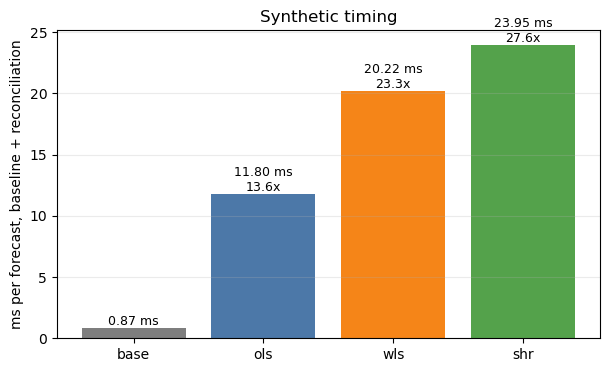

In [5]:
timing_view = timing_results.copy()
timing_view = timing_view[[
    "method", "n_forecasts", "baseline_ms_per_forecast",
    "reconciliation_ms_per_forecast", "total_ms_per_forecast",
    "slowdown_vs_base", "failed",
]].rename(columns={
    "baseline_ms_per_forecast": "baseline, ms/forecast",
    "reconciliation_ms_per_forecast": "NLCR overhead, ms/forecast",
    "total_ms_per_forecast": "total, ms/forecast",
    "slowdown_vs_base": "slowdown vs baseline",
})

display(
    timing_view.style.format({
        "baseline, ms/forecast": "{:.3f}",
        "NLCR overhead, ms/forecast": "{:.3f}",
        "total, ms/forecast": "{:.3f}",
        "slowdown vs baseline": "{:.1f}x",
    })
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_data = timing_results.set_index("method")["total_ms_per_forecast"].reindex(["base", "ols", "wls", "shr"])
bars = ax.bar(plot_data.index, plot_data.values, color=["#7E7E7E", "#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("ms per forecast, baseline + reconciliation")
ax.set_title("Synthetic timing")
ax.grid(axis="y", alpha=0.25)
for bar, method in zip(bars, plot_data.index):
    row = timing_results[timing_results["method"] == method].iloc[0]
    label = f"{row['total_ms_per_forecast']:.2f} ms"
    if method != "base":
        label += f"\n{row['slowdown_vs_base']:.1f}x"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)
fig.savefig(RESULTS_DIR / "figures" / "synthetic_timing.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)


## Метрики и графики

In [6]:
metric_tables = []
stat_test_tables = []
loss_improvement_tables = []

for method, y_method in y_reconciled_by_method.items():
    method_metrics = compare_forecasts(y_true, y_base, y_method, constraints)
    method_metrics["p_reconciled_better"] = method_metrics.attrs["p_reconciled_better"]
    method_metrics["method"] = method_metrics["forecast"].where(method_metrics["forecast"] == "base", method)
    method_metrics = method_metrics[method_metrics["forecast"] != "base"]
    metric_tables.append(method_metrics)

    method_stat_tests = paired_forecast_tests(y_true, y_base, y_method)
    method_stat_tests.insert(0, "method", method)
    stat_test_tables.append(method_stat_tests)

    method_loss_improvements = paired_loss_improvements(y_true, y_base, y_method)
    method_loss_improvements.insert(0, "method", method)
    loss_improvement_tables.append(method_loss_improvements)

base_metrics = compare_forecasts(y_true, y_base, y_reconciled_by_method["ols"], constraints)
base_metrics = base_metrics[base_metrics["forecast"] == "base"].copy()
base_metrics["p_reconciled_better"] = pd.NA
base_metrics["method"] = "base"

metrics = pd.concat([base_metrics, *metric_tables], ignore_index=True)
metrics.to_csv(RESULTS_DIR / "tables" / "synthetic_metrics.csv", index=False)

stat_tests = pd.concat(stat_test_tables, ignore_index=True)
stat_tests.to_csv(RESULTS_DIR / "tables" / "synthetic_stat_tests.csv", index=False)

loss_improvements = pd.concat(loss_improvement_tables, ignore_index=True)
loss_improvements.to_csv(RESULTS_DIR / "tables" / "synthetic_loss_improvements.csv", index=False)

display(stat_tests)
metrics

,method,metric,base_loss,nlcr_loss,mean_improvement,relative_improvement_pct,win_rate,wilcoxon_stat,wilcoxon_p,sign_p,bootstrap_ci_low,bootstrap_ci_high,n_observations,n_non_ties
0,ols,mae,1.487418,1.475515,0.011904,0.800288,0.4625,1731.0,2.972287e-01,7.829789e-01,-0.005484,0.030807,80,80
1,ols,rmse,2.398825,2.373760,0.025065,1.044898,0.9875,3239.0,4.076179e-15,6.700163e-23,0.013424,0.035555,80,80
2,ols,smape,0.094479,0.101721,-0.007242,-7.665028,0.2000,622.0,9.999992e-01,1.000000e+00,-0.010584,-0.003883,80,80
3,wls,mae,1.487418,1.393044,0.094374,6.344852,0.8875,3079.0,1.300222e-12,2.186989e-13,0.079085,0.115865,80,80
4,wls,rmse,2.398825,2.238902,0.159923,6.666728,0.8250,3026.0,7.726552e-12,1.568271e-09,0.135146,0.210063,80,80
5,wls,smape,0.094479,0.092184,0.002296,2.429795,0.7000,2416.0,6.731134e-05,2.257586e-04,0.001197,0.003447,80,80
6,shr,mae,1.487418,1.095981,0.391437,26.316531,0.8500,3027.0,7.475451e-12,6.008243e-11,0.257642,0.460704,80,80
7,shr,rmse,2.398825,1.760923,0.637902,26.592285,0.8375,2999.0,1.869347e-11,3.207571e-10,0.409093,0.756026,80,80
8,shr,smape,0.094479,0.067735,0.026745,28.307428,0.8875,3069.0,1.828761e-12,2.186989e-13,0.020727,0.032975,80,80


,forecast,mae,rmse,smape,constraint_violation,p_reconciled_better,method
0,base,1.487418,2.566804,0.094479,1.498082e+00,<NA>,base
1,nlcr,1.475515,2.545993,0.101721,9.997764e-12,0.9875,ols
2,nlcr,1.393044,2.423374,0.092184,1.346661e-12,0.825,wls
3,nlcr,1.095981,1.917519,0.067735,5.058530e-13,0.8375,shr


## Статистические тесты

Для `mae`, `rmse` и `smape` сравниваем парные row-wise ошибки базового прогноза и NLCR. Положительное `mean_improvement` означает, что NLCR уменьшил ошибку.


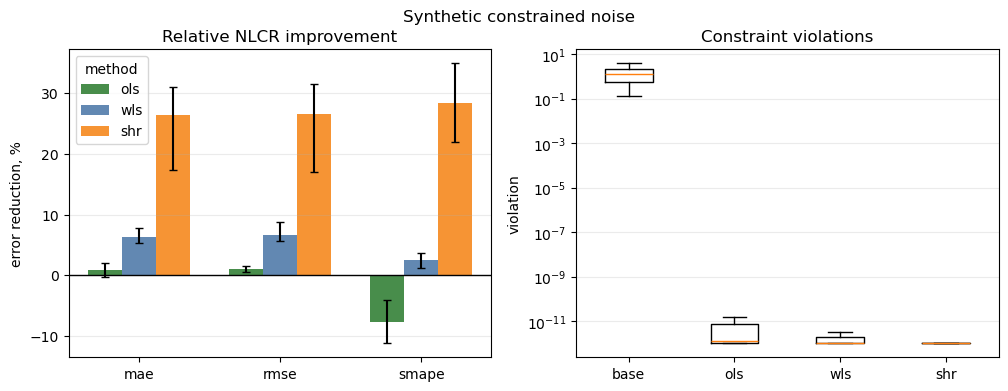

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_relative_improvements(stat_tests, ax=axes[0])
plot_constraint_violations(y_base, y_reconciled_by_method, constraints, ax=axes[1])
fig.suptitle("Synthetic constrained noise")
fig.savefig(RESULTS_DIR / "figures" / "synthetic_experiment.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

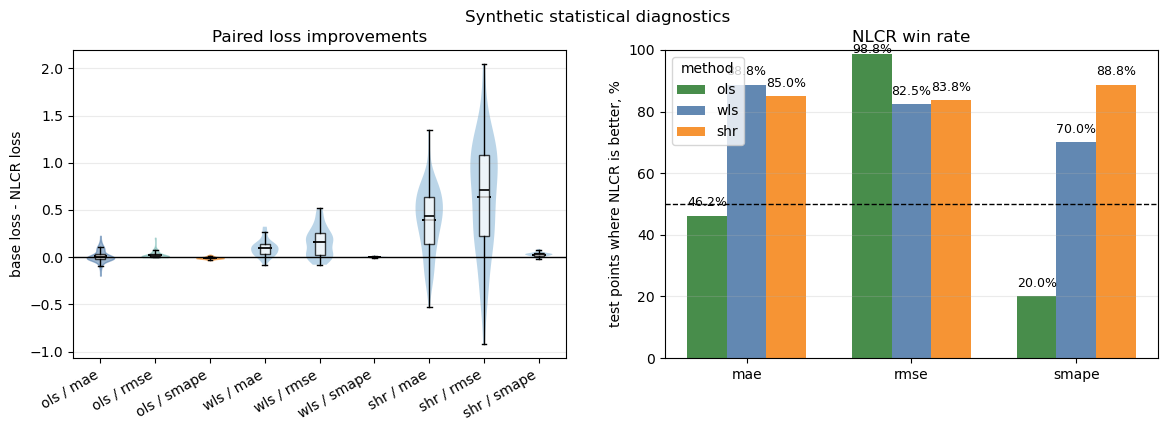

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_paired_improvement_distributions(loss_improvements, ax=axes[0])
plot_win_rates(stat_tests, ax=axes[1])
fig.suptitle("Synthetic statistical diagnostics")
fig.savefig(RESULTS_DIR / "figures" / "synthetic_stat_tests.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

## Выводы по результатам эксперимента

- NLCR практически полностью устраняет нарушение ограничений: mean violation снижается с `1.498` у базового прогноза до порядка `1e-12` после reconciliation.
- Лучший результат показал `shr`: MAE `1.488 -> 1.096`, RMSE `2.567 -> 1.918`, SMAPE `0.094 -> 0.068`; относительное улучшение составляет `26-28%` по всем метрикам.
- `wls` также устойчиво улучшает все метрики, тогда как `ols` улучшает RMSE, но ухудшает SMAPE. Это подтверждает, что учет covariance ошибок важен даже в контролируемой синтетической задаче.
- Вероятная причина сильного эффекта: истинные данные точно удовлетворяют ограничениям, а независимый baseline создает несогласованные прогнозы, которые NLCR эффективно исправляет.

- Baseline требует `0.87` мс на прогноз. Полное время `baseline + NLCR` составляет `11.80` мс для `ols`, `20.22` мс для `wls` и `23.95` мс для `shr`, то есть замедление относительно baseline равно `13.6x`, `23.3x` и `27.6x`. В этой задаче выигрыш `shr` в точности сопровождается наибольшей вычислительной стоимостью.